Isolation Forest:

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Load the dataset
df = pd.read_csv("C://Users//israt//HD lab//My Project//Dataset//Airsage Dataset//NebraskaLakes_Cleaned_round.csv")

# Basic preprocessing
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['count', 'duration'])

# Add day name and day type (Weekday or Weekend)
df['day_of_week'] = df['date'].dt.day_name()
df['day_type'] = df['date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')


print(f"Total number of rows: {len(df)}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['count', 'duration']])

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['anomaly_label'] = iso_forest.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal

# Convert label: 1 -> 0 (normal), -1 -> 1 (anomaly)
df['anomaly_label'] = df['anomaly_label'].map({1: 0, -1: 1})

# Anomaly scores: flip decision_function so higher = more anomalous
df['anomaly_score'] = -iso_forest.decision_function(X_scaled)

# Print all rows with scores
#print("All points with anomaly scores (Isolation Forest):")
#print(df[['poi', 'date', 'count', 'duration', 'anomaly_label', 'anomaly_score']])
print(f"Total number of anomalies detected: {df['anomaly_label'].sum()}")
print(f"Total number of normal points: {(df['anomaly_label'] == 0).sum()}") 






C:\Users\israt\AppData\Local\Temp\ipykernel_26284\1725214512.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C://Users//israt//HD lab//My Project//Dataset//Airsage Dataset//NebraskaLakes_Cleaned_round.csv")


Total number of rows: 123627
Total number of anomalies detected: 12362
Total number of normal points: 111265


In [2]:
top_by_score = df.sort_values(by='anomaly_score', ascending=False).head(20)
print("\nTop points by raw anomaly score (regardless of label):")
print(top_by_score[['poi', 'date', 'day_type', 'count', 'duration', 'anomaly_label']])



Top points by raw anomaly score (regardless of label):
                    poi       date day_type   count    duration  anomaly_label
32434            Holmes 2022-05-04  Weekday  2970.0  155.472078              1
31733  Glenn Cunningham 2022-05-31  Weekday  2975.0  185.583333              1
32471            Holmes 2022-05-09  Weekday  2939.0  168.278229              1
32464            Holmes 2022-05-08  Weekend  2856.0  156.809850              1
32480            Holmes 2022-05-10  Weekday  2845.0  177.921468              1
32554            Holmes 2022-05-21  Weekend  2779.0  154.430766              1
32451            Holmes 2022-05-06  Weekday  2749.0  158.087151              1
32442            Holmes 2022-05-05  Weekday  2753.0  169.791736              1
32417            Holmes 2022-05-02  Weekday  2703.0  139.296528              1
32524            Holmes 2022-05-17  Weekday  2698.0  130.560173              1
28815       Carter Lake 2022-05-31  Weekday  2615.0  134.247475            

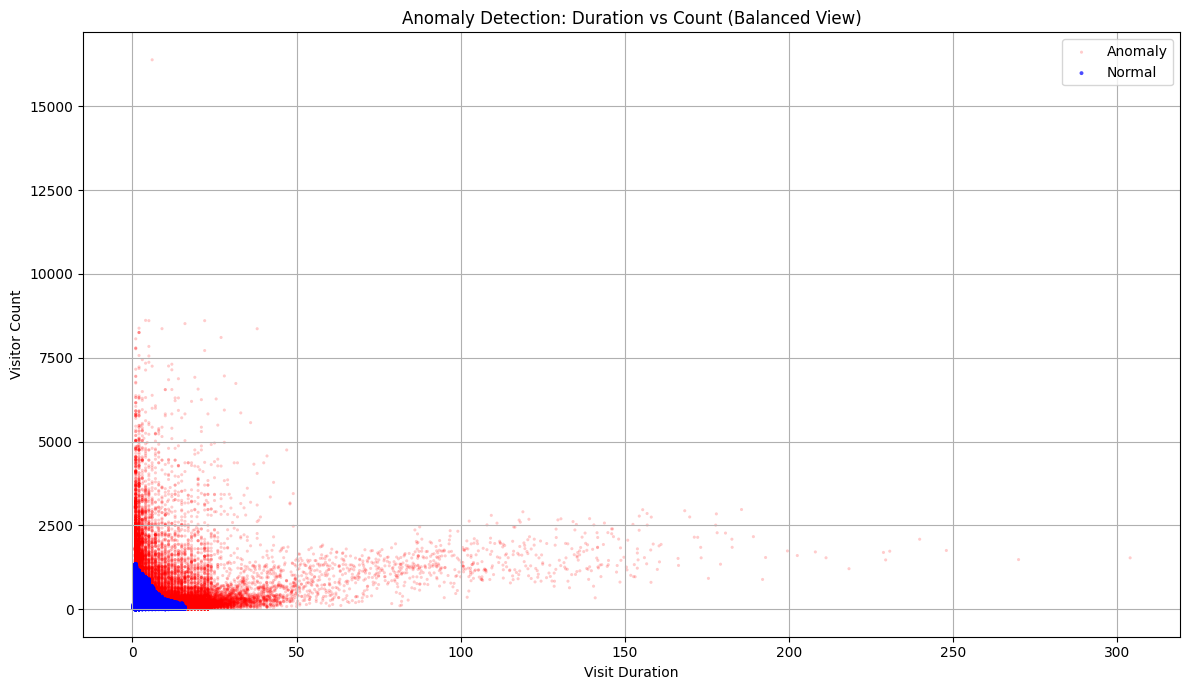

In [3]:
import matplotlib.pyplot as plt

# Separate normal and anomaly points
anomalies = df[df['anomaly_label'] == 1]
normal = df[df['anomaly_label'] == 0]

plt.figure(figsize=(12, 7))

# 1. Plot anomalies with small, light red markers
plt.scatter(anomalies['duration'], anomalies['count'],
            c='red', label='Anomaly', alpha=0.2, s=5, edgecolor='none')

# 2. Plot normal points last, so they appear on top
plt.scatter(normal['duration'], normal['count'],
            c='blue', label='Normal', alpha=0.7, s=8, edgecolor='none')

# Optional: Apply log scale to better distribute values
#plt.xscale('log')
#plt.yscale('log')

# Titles and labels
plt.xlabel('Visit Duration')
plt.ylabel('Visitor Count')
plt.title('Anomaly Detection: Duration vs Count (Balanced View)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


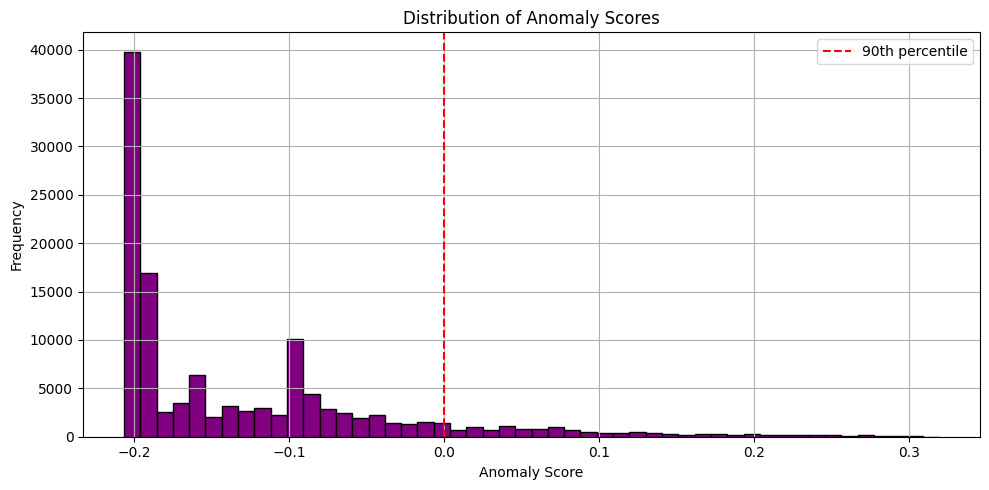

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df['anomaly_score'], bins=50, color='purple', edgecolor='black')
plt.axvline(df['anomaly_score'].quantile(0.90), color='red', linestyle='--', label='90th percentile')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anomaly Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


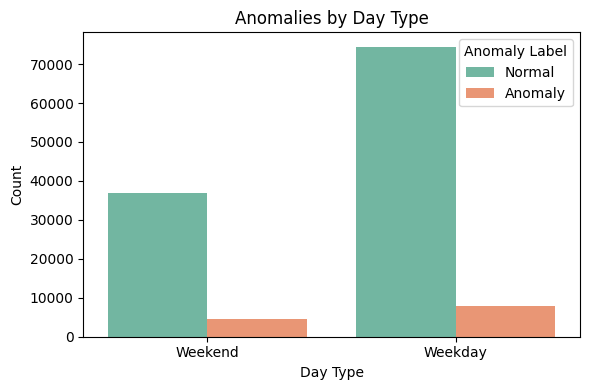

In [6]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='day_type', hue='anomaly_label', palette='Set2')
plt.title('Anomalies by Day Type')
plt.xlabel('Day Type')
plt.ylabel('Count')
plt.legend(title='Anomaly Label', labels=['Normal', 'Anomaly'])
plt.tight_layout()
plt.show()


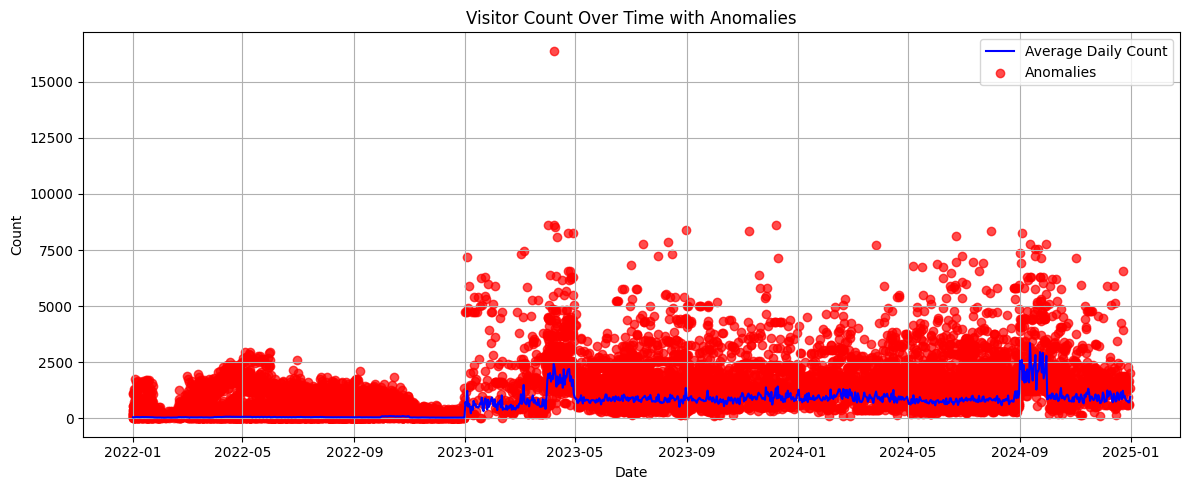

In [7]:
# Daily mean count with anomalies overlaid
daily = df.groupby('date')['count'].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily.values, label='Average Daily Count', color='blue')

# Overlay anomalies
anomalies = df[df['anomaly_label'] == 1]
plt.scatter(anomalies['date'], anomalies['count'], color='red', label='Anomalies', alpha=0.7)

plt.title('Visitor Count Over Time with Anomalies')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ======================
# Step 0: Load & prepare
# ======================
df = pd.read_csv(
    r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv",
    low_memory=False
)

# Clean types
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df = df.dropna(subset=['date', 'count', 'duration']).copy()

# Calendar features
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# Add anomaly features
X_ad = StandardScaler().fit_transform(df[['count','duration']])
iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X_ad)
score = -iso.decision_function(X_ad)

df['anomaly_label'] = (pred == -1).astype(int)
df['anomaly_score'] = score

# ======================
# Step 1: Train initial model to get feature importances
# ======================
all_features = ['month','dow','is_weekend','duration','anomaly_score','anomaly_label']
X = df[all_features]
y = df['count']

X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

initial_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)
initial_model.fit(X_train_full, y_train)

# ======================
# Step 2: Select top 5 most important features
# ======================
importances = initial_model.feature_importances_
importance_series = pd.Series(importances, index=all_features).sort_values(ascending=False)
top_features = importance_series.head(5).index.tolist()

print("Top 5 Important Features:", top_features)

# ======================
# Step 3: Retrain model on top features
# ======================
X_top = df[top_features]
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
model.fit(X_train, y_train)

# ======================
# Step 4: Evaluate
# ======================
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("\nPerformance Using Top Features Only:")
print("Train R² Score:", round(r2_score(y_train, y_train_pred),4))
print("Test R² Score:",  round(r2_score(y_test, y_test_pred),4))
print("Test MAE:", round(mean_absolute_error(y_test, y_test_pred),3))


Top 5 Important Features: ['anomaly_score', 'duration', 'month', 'dow', 'is_weekend']

Performance Using Top Features Only:
Train R² Score: 0.9991
Test R² Score: 0.9852
Test MAE: 6.6


In [2]:
# ======================
# Step 2: CLEAN (remove anomalies from training)
# ======================
df_clean = df[df['anomaly_label'] == 0]

X_c = df_clean[all_features]
y_c = df_clean['count']

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

model_clean = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
model_clean.fit(X_train_clean, y_train_clean)

y_train_pred_clean = model_clean.predict(X_train_clean)
y_test_pred_clean  = model_clean.predict(X_test_clean)

print("\nCLEAN (anomalies removed from training):")
print("Train R²:", round(r2_score(y_train_clean, y_train_pred_clean),4))
print("Test  R²:", round(r2_score(y_test_clean,  y_test_pred_clean),4))
print("Train MAE:", round(mean_absolute_error(y_train_clean, y_train_pred_clean),3))
print("Test  MAE:", round(mean_absolute_error(y_test_clean,  y_test_pred_clean),3))


CLEAN (anomalies removed from training):
Train R²: 0.9992
Test  R²: 0.9982
Train MAE: 1.209
Test  MAE: 1.995


In [70]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# ======================
# Step 0: Load & prepare
# ======================
df = pd.read_csv(
    r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv",
    low_memory=False
)

# Clean types
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df = df.dropna(subset=['date', 'count', 'duration']).copy()

# Calendar features
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# ======================
# Step A: Anomaly features (same as before)
# ======================
X_ad = StandardScaler().fit_transform(df[['count','duration']])
iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X_ad)
score = -iso.decision_function(X_ad)

df['anomaly_label'] = (pred == -1).astype(int)
df['anomaly_score'] = score

# ======================
# Step B: Build feature matrix (ALL NUMERIC FEATURES)
# ======================
# Use every numeric column except the target 'count'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'count']

X_all = df[feature_cols].fillna(0)
y = df['count'].values

# Train/val split
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ======================
# Step C: Initial XGBoost to get importances
# ======================
xgb_full = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_full.fit(X_train_full, y_train)

# Evaluate with ALL features (optional baseline)
y_train_pred_full = xgb_full.predict(X_train_full)
y_test_pred_full = xgb_full.predict(X_test_full)
print("=== XGBoost (ALL numeric features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred_full), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred_full), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred_full), 3))

# ======================
# Step D: Top-10 features by importance
# ======================
importances = xgb_full.feature_importances_
imp_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top10_features = imp_series.head(10).index.tolist()

print("\nTop 10 Important Features (XGBoost):")
for i, f in enumerate(top10_features, 1):
    print(f"{i}. {f}  (score={imp_series[f]:.6f})")

# ======================
# Step E: Retrain XGBoost on TOP-10 features only
# ======================
X_top = df[top10_features].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

xgb_top10 = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_top10.fit(X_train, y_train)

# Evaluate TOP-10 model
y_train_pred = xgb_top10.predict(X_train)
y_test_pred = xgb_top10.predict(X_test)
7
print("\n=== XGBoost (TOP-10 features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred), 3))




=== XGBoost (ALL numeric features) ===
Train R²: 0.9999
Test  R²: 0.9862
Test  MAE: 5.06

Top 10 Important Features (XGBoost):
1. white  (score=0.593428)
2. male_45_49  (score=0.071544)
3. male_35_39  (score=0.037574)
4. female_45_49  (score=0.036043)
5. anomaly_score  (score=0.030550)
6. black  (score=0.029215)
7. female_35_39  (score=0.022473)
8. female_40_44  (score=0.020247)
9. female_5_9  (score=0.018268)
10. female_50_54  (score=0.017868)

=== XGBoost (TOP-10 features) ===
Train R²: 0.999
Test  R²: 0.9816
Test  MAE: 9.64


In [5]:
# ======================
# RandomForestRegressor: ALL features -> importance -> TOP-10 -> retrain
# (Reuses: feature_cols, X_all, X_train_full, X_test_full, y_train, y_test)
# ======================
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# ---- Train RF on ALL numeric features ----
rf_full = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,          # set 20 if you want more regularization
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",     # robust default
    n_jobs=-1,
    random_state=42
)
rf_full.fit(X_train_full, y_train)

# Baseline evaluation (ALL features)
y_train_pred_full_rf = rf_full.predict(X_train_full)
y_test_pred_full_rf  = rf_full.predict(X_test_full)
print("\n=== RandomForest (ALL numeric features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred_full_rf), 4))
print("Test  R²:", round(r2_score(y_test,  y_test_pred_full_rf), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred_full_rf), 3))

# ---- Top-10 features by importance ----
rf_importances = rf_full.feature_importances_
rf_imp_series = pd.Series(rf_importances, index=feature_cols).sort_values(ascending=False)
rf_top10_features = rf_imp_series.head(10).index.tolist()

print("\nTop 10 Important Features (RandomForest):")
for i, f in enumerate(rf_top10_features, 1):
    print(f"{i}. {f}  (score={rf_imp_series[f]:.6f})")

# ---- Retrain RF on TOP-10 features ----
X_top_rf = X_all[rf_top10_features]
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_top_rf, y, test_size=0.2, random_state=42
)

rf_top10 = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)
rf_top10.fit(X_train_rf, y_train_rf)

# Evaluate TOP-10 model
y_train_pred_rf = rf_top10.predict(X_train_rf)
y_test_pred_rf  = rf_top10.predict(X_test_rf)

print("\n=== RandomForest (TOP-10 features) ===")
print("Train R²:", round(r2_score(y_train_rf, y_train_pred_rf), 4))
print("Test  R²:", round(r2_score(y_test_rf,  y_test_pred_rf), 4))
print("Test  MAE:", round(mean_absolute_error(y_test_rf, y_test_pred_rf), 3))

# Optional: show the top-10 table nicely
print("\nTop-10 importance table:\n",
      rf_imp_series.head(10).reset_index().rename(columns={"index": "feature", 0: "importance"}))



=== RandomForest (ALL numeric features) ===
Train R²: 0.9991
Test  R²: 0.982
Test  MAE: 5.322

Top 10 Important Features (RandomForest):
1. white  (score=0.119718)
2. income_60_75  (score=0.068899)
3. male_45_49  (score=0.064257)
4. female_45_49  (score=0.059436)
5. female_50_54  (score=0.058858)
6. female_55_59  (score=0.051128)
7. female_35_39  (score=0.050003)
8. male_50_54  (score=0.041015)
9. income_75_100  (score=0.035979)
10. male_5_9  (score=0.035897)

=== RandomForest (TOP-10 features) ===
Train R²: 0.9984
Test  R²: 0.9769
Test  MAE: 9.539

Top-10 importance table:
          feature  importance
0          white    0.119718
1   income_60_75    0.068899
2     male_45_49    0.064257
3   female_45_49    0.059436
4   female_50_54    0.058858
5   female_55_59    0.051128
6   female_35_39    0.050003
7     male_50_54    0.041015
8  income_75_100    0.035979
9       male_5_9    0.035897


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# ======================
# Step 0: Load & prepare
# ======================
df = pd.read_csv(
    r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv",
    low_memory=False
)

# Clean types
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df = df.dropna(subset=['date', 'count', 'duration']).copy()

# Calendar features
df['month'] = df['date'].dt.month
df['dow'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['dow'] >= 5).astype(int)

# ======================
# Step A: Anomaly features (same as before)
# ======================
X_ad = StandardScaler().fit_transform(df[['count','duration']])
iso = IsolationForest(contamination=0.10, random_state=42)
pred = iso.fit_predict(X_ad)
score = -iso.decision_function(X_ad)

df['anomaly_label'] = (pred == -1).astype(int)
df['anomaly_score'] = score

# ======================
# Step B: Build feature matrix (ALL NUMERIC FEATURES)
# ======================
# Use every numeric column except the target 'count'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != 'count']

X_all = df[feature_cols].fillna(0)
y = df['count'].values

# Train/val split
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ======================
# Step C: Initial XGBoost to get importances
# ======================
xgb_full = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_full.fit(X_train_full, y_train)

# Evaluate with ALL features (optional baseline)
y_train_pred_full = xgb_full.predict(X_train_full)
y_test_pred_full = xgb_full.predict(X_test_full)
print("=== XGBoost (ALL numeric features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred_full), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred_full), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred_full), 3))

# ======================
# Step D: Top-10 features by importance
# ======================
importances = xgb_full.feature_importances_
imp_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top10_features = imp_series.head(10).index.tolist()

print("\nTop 10 Important Features (XGBoost):")
for i, f in enumerate(top10_features, 1):
    print(f"{i}. {f}  (score={imp_series[f]:.6f})")

# ======================
# Step E: Retrain XGBoost on TOP-10 features only
# ======================
X_top = df[top10_features].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

xgb_top10 = XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_top10.fit(X_train, y_train)

# Evaluate TOP-10 model
y_train_pred = xgb_top10.predict(X_train)
y_test_pred = xgb_top10.predict(X_test)

print("\n=== XGBoost (TOP-10 features) ===")
print("Train R²:", round(r2_score(y_train, y_train_pred), 4))
print("Test  R²:", round(r2_score(y_test, y_test_pred), 4))
print("Test  MAE:", round(mean_absolute_error(y_test, y_test_pred), 3))

# (Optional) Show the top-10 importance table nicely
top10_table = imp_series.head(10).reset_index()
top10_table.columns = ["feature", "importance"]
print("\nTop-10 importance table:\n", top10_table)


=== XGBoost (ALL numeric features) ===
Train R²: 0.9999
Test  R²: 0.9862
Test  MAE: 5.06

Top 10 Important Features (XGBoost):
1. white  (score=0.593428)
2. male_45_49  (score=0.071544)
3. male_35_39  (score=0.037574)
4. female_45_49  (score=0.036043)
5. anomaly_score  (score=0.030550)
6. black  (score=0.029215)
7. female_35_39  (score=0.022473)
8. female_40_44  (score=0.020247)
9. female_5_9  (score=0.018268)
10. female_50_54  (score=0.017868)

=== XGBoost (TOP-10 features) ===
Train R²: 0.999
Test  R²: 0.9816
Test  MAE: 9.64

Top-10 importance table:
          feature  importance
0          white    0.593428
1     male_45_49    0.071544
2     male_35_39    0.037574
3   female_45_49    0.036043
4  anomaly_score    0.030550
5          black    0.029215
6   female_35_39    0.022473
7   female_40_44    0.020247
8     female_5_9    0.018268
9   female_50_54    0.017868


Weekend Visitors: Friday Evening vs Sat/Sun (May–Aug)
        Friday (Evening)  Saturday (Full day)  Sunday (Full day)
month                                                           
May               327257               527519             536278
June              517736               740561             746087
July              555929               689120             660801
August            406150               629842             423920

Saved summary to: weekend_summary_may_aug.csv


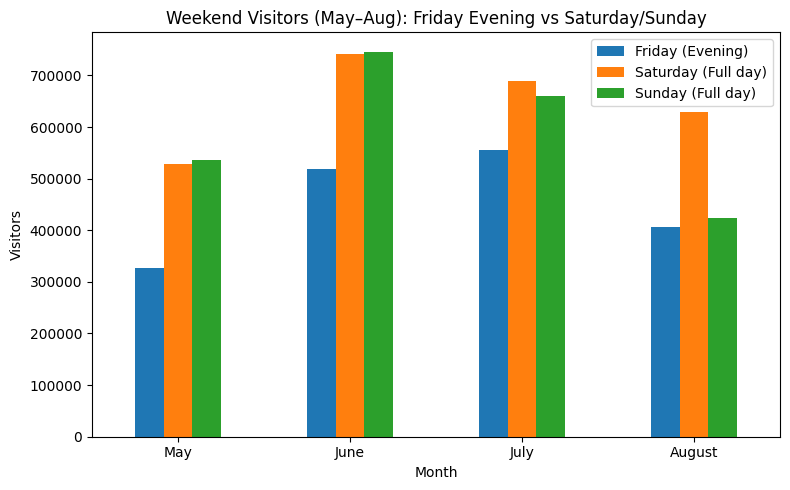

In [4]:
# %%
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
CSV_PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
MONTHS_OF_INTEREST = [5, 6, 7, 8]  # May–Aug
EVENING_START_HOUR = 17            # 5 PM
EVENING_HOURS = [f"hh{str(h).zfill(2)}" for h in range(EVENING_START_HOUR, 24)]

# ---------- LOAD ----------
df = pd.read_csv(CSV_PATH, low_memory=False)

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")

# Keep only May–Aug
df = df[df["date"].dt.month.isin(MONTHS_OF_INTEREST)].copy()

# Day-of-week name
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month

# ---------- VALIDATE HOUR COLUMNS ----------
hour_cols = [c for c in df.columns if c.startswith("hh") and len(c) == 4 and c[2:].isdigit()]
missing_evening = [c for c in EVENING_HOURS if c not in hour_cols]
if missing_evening:
    raise ValueError(f"Missing expected hour columns for evening: {missing_evening}")

# ---------- FRIDAY EVENING (5 PM–MIDNIGHT) ----------
is_friday = df["day_of_week"].eq("Friday")
df.loc[is_friday, "friday_evening"] = df.loc[is_friday, EVENING_HOURS].sum(axis=1)

# ---------- FULL-DAY SATURDAY & SUNDAY ----------
sat = df[df["day_of_week"].eq("Saturday")]
sun = df[df["day_of_week"].eq("Sunday")]

# Aggregate by month
fri_eve_by_month = (
    df[df["day_of_week"].eq("Friday")]
    .groupby("month", as_index=True)["friday_evening"]
    .sum()
    .rename("Friday (Evening)")
)
sat_by_month = sat.groupby("month", as_index=True)["count"].sum().rename("Saturday (Full day)")
sun_by_month = sun.groupby("month", as_index=True)["count"].sum().rename("Sunday (Full day)")

# ---------- COMBINE & ORDER ROWS AS May..Aug ----------
summary = pd.concat([fri_eve_by_month, sat_by_month, sun_by_month], axis=1).fillna(0).astype(int)
month_name = {5: "May", 6: "June", 7: "July", 8: "August"}
summary.index = summary.index.map(month_name.get)
summary = summary.loc[["May", "June", "July", "August"]]

# ---------- SAVE & PRINT ----------
out_csv = "weekend_summary_may_aug.csv"
summary.to_csv(out_csv, index=True)

print("Weekend Visitors: Friday Evening vs Sat/Sun (May–Aug)")
print(summary)
print(f"\nSaved summary to: {out_csv}")

# ---------- PLOT (Grouped Bar) ----------
ax = summary.plot(kind="bar", rot=0, figsize=(8, 5))
ax.set_title("Weekend Visitors (May–Aug): Friday Evening vs Saturday/Sunday")
ax.set_xlabel("Month")
ax.set_ylabel("Visitors")
plt.tight_layout()
plt.show()


Weekend Visitors by Daypart (May–Aug)
        Friday (Morning)  Saturday (Morning)  Sunday (Morning)  \
month                                                            
May               183693              286938            292821   
June              195996              369541            432299   
July              250155              411482            363444   
August            205110              439383            303986   

        Friday (Evening)  Saturday (Evening)  Sunday (Evening)  \
month                                                            
May               233402              288716            232395   
June              335819              548452            392028   
July              386840              502670            378186   
August            273437              434685            193925   

        Friday (Night)  Saturday (Night)  Sunday (Night)  
month                                                     
May              93855            100404          

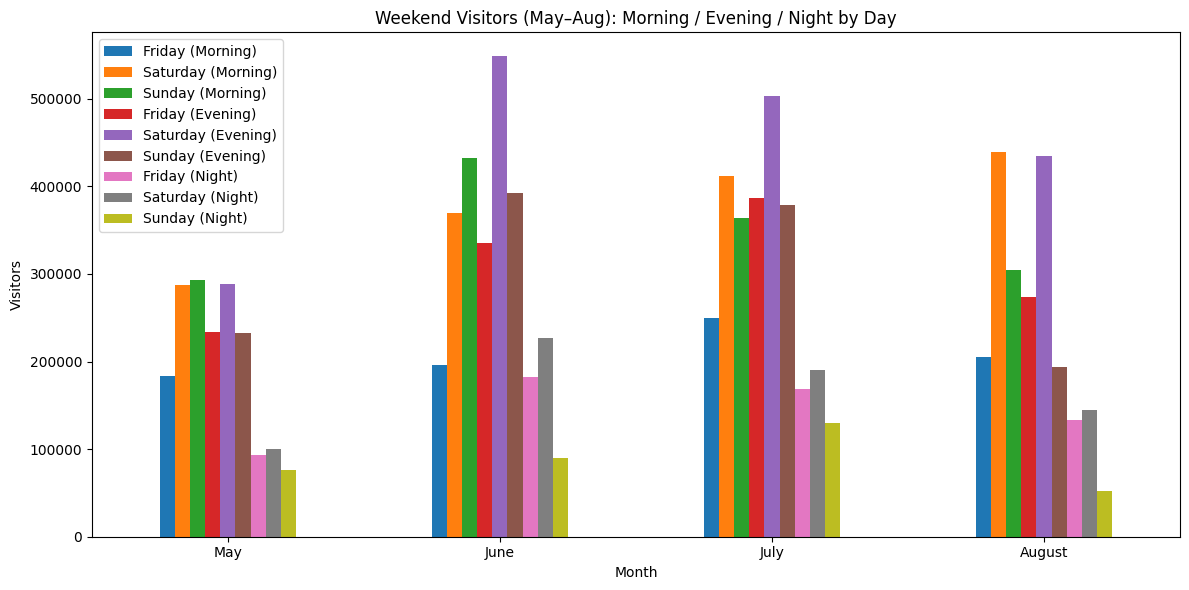

In [2]:
# %%
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
CSV_PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
MONTHS_OF_INTEREST = [5, 6, 7, 8]  # May–Aug
MONTH_NAME = {5: "May", 6: "June", 7: "July", 8: "August"}

# Time windows (24h)
WINDOWS = {
    "Morning": list(range(6, 12)),   # 06–11
    "Evening": list(range(17, 21)),  # 17–20
    "Night":   list(range(21, 24)),  # 21–23
}

WEEKDAYS = ["Friday", "Saturday", "Sunday"]

# ---------- HELPERS ----------
def hh_cols(hours):
    return [f"hh{str(h).zfill(2)}" for h in hours]

# ---------- LOAD ----------
df = pd.read_csv(CSV_PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df = df[df["date"].dt.month.isin(MONTHS_OF_INTEREST)].copy()
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month

# Validate required hour columns
needed_cols = sorted(set(sum([hh_cols(hs) for hs in WINDOWS.values()], [])))
missing_any = [c for c in needed_cols if c not in df.columns]
if missing_any:
    raise ValueError(f"Missing expected hour columns: {missing_any}")

# ---------- BUILD MONTHLY SUMMARY ----------
pieces = []
for wd in WEEKDAYS:
    dwd = df[df["day_of_week"].eq(wd)].copy()
    for win_name, hours in WINDOWS.items():
        cols = hh_cols(hours)
        dwd[f"{wd}_{win_name}"] = dwd[cols].sum(axis=1)
        agg = (
            dwd.groupby("month", as_index=True)[f"{wd}_{win_name}"]
            .sum()
            .rename(f"{wd} ({win_name})")
        )
        pieces.append(agg)

summary = pd.concat(pieces, axis=1).fillna(0).astype(int)

# Reindex months as names, in May→Aug order
summary.index = summary.index.map(MONTH_NAME.get)
summary = summary.loc[["May", "June", "July", "August"]]

# ---------- REORDER COLUMNS: Morning → Evening → Night ----------
ordered_cols = []
for win_name in ["Morning", "Evening", "Night"]:
    for wd in WEEKDAYS:  # Friday, Saturday, Sunday
        col = f"{wd} ({win_name})"
        if col in summary.columns:
            ordered_cols.append(col)

# Ensure no column is left behind
summary = summary[[c for c in ordered_cols if c in summary.columns]]

# ---------- SAVE & PRINT ----------
out_csv = "weekend_dayparts_may_aug.csv"
summary.to_csv(out_csv, index=True)

print("Weekend Visitors by Daypart (May–Aug)")
print(summary)
print(f"\nSaved summary to: {out_csv}")

# ---------- PLOT ----------
ax = summary.plot(kind="bar", rot=0, figsize=(12, 6))
ax.set_title("Weekend Visitors (May–Aug): Morning / Evening / Night by Day")
ax.set_xlabel("Month")
ax.set_ylabel("Visitors")
plt.tight_layout()
plt.show()


Weekend Visitors by Daypart (May–Aug)
        Saturday (Morning)  Sunday (Morning)  Friday (Evening)  \
month                                                            
May                 286938            292821            233402   
June                369541            432299            335819   
July                411482            363444            386840   
August              439383            303986            273437   

        Saturday (Evening)  Sunday (Evening)  Friday (Night)  \
month                                                          
May                 288716            232395           93855   
June                548452            392028          181917   
July                502670            378186          169089   
August              434685            193925          132713   

        Saturday (Night)  Sunday (Night)  
month                                     
May               100404           76430  
June              226397           89570  
July    

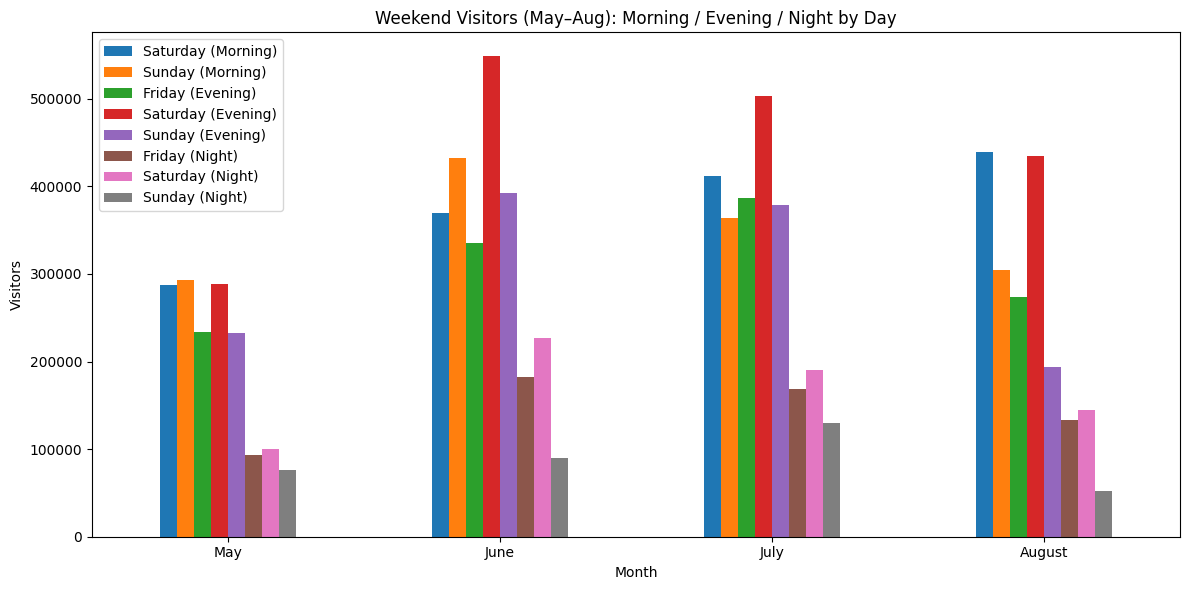

In [3]:
# %%
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
CSV_PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
MONTHS_OF_INTEREST = [5, 6, 7, 8]  # May–Aug
MONTH_NAME = {5: "May", 6: "June", 7: "July", 8: "August"}

# Time windows (24h)
WINDOWS = {
    "Morning": list(range(6, 12)),   # 06–11
    "Evening": list(range(17, 21)),  # 17–20
    "Night":   list(range(21, 24)),  # 21–23
}

WEEKDAYS = ["Friday", "Saturday", "Sunday"]

# ---------- HELPERS ----------
def hh_cols(hours):
    return [f"hh{str(h).zfill(2)}" for h in hours]

# ---------- LOAD ----------
df = pd.read_csv(CSV_PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df = df[df["date"].dt.month.isin(MONTHS_OF_INTEREST)].copy()
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month

# Validate required hour columns
needed_cols = sorted(set(sum([hh_cols(hs) for hs in WINDOWS.values()], [])))
missing_any = [c for c in needed_cols if c not in df.columns]
if missing_any:
    raise ValueError(f"Missing expected hour columns: {missing_any}")

# ---------- BUILD MONTHLY SUMMARY ----------
pieces = []
for wd in WEEKDAYS:
    dwd = df[df["day_of_week"].eq(wd)].copy()
    for win_name, hours in WINDOWS.items():
        cols = hh_cols(hours)
        dwd[f"{wd}_{win_name}"] = dwd[cols].sum(axis=1)
        agg = (
            dwd.groupby("month", as_index=True)[f"{wd}_{win_name}"]
            .sum()
            .rename(f"{wd} ({win_name})")
        )
        pieces.append(agg)

summary = pd.concat(pieces, axis=1).fillna(0).astype(int)

# Reindex months as names, in May→Aug order
summary.index = summary.index.map(MONTH_NAME.get)
summary = summary.loc[["May", "June", "July", "August"]]

# ---------- REORDER COLUMNS ----------
ordered_cols = [
    "Saturday (Morning)", "Sunday (Morning)",
    "Friday (Evening)", "Saturday (Evening)", "Sunday (Evening)",
    "Friday (Night)", "Saturday (Night)", "Sunday (Night)"
]
summary = summary[[c for c in ordered_cols if c in summary.columns]]

# ---------- SAVE & PRINT ----------
out_csv = "weekend_dayparts_may_aug.csv"
summary.to_csv(out_csv, index=True)

print("Weekend Visitors by Daypart (May–Aug)")
print(summary)
print(f"\nSaved summary to: {out_csv}")

# ---------- PLOT ----------
ax = summary.plot(kind="bar", rot=0, figsize=(12, 6))
ax.set_title("Weekend Visitors (May–Aug): Morning / Evening / Night by Day")
ax.set_xlabel("Month")
ax.set_ylabel("Visitors")
plt.tight_layout()
plt.show()


               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
      group1             group2        meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------------------
August-Fri-Evening August-Fri-Morning  -38.9106 0.9595 -105.7992    27.978  False
August-Fri-Evening   August-Fri-Night   -80.139 0.0023 -147.0275  -13.2504   True
August-Fri-Evening August-Sat-Evening   51.5732 0.3972  -12.5385  115.6848  False
August-Fri-Evening August-Sat-Morning   53.8135 0.2985  -10.2982  117.9252  False
August-Fri-Evening   August-Sat-Night  -86.5618 0.0001 -150.6735  -22.4501   True
August-Fri-Evening August-Sun-Evening   -49.339 0.5891 -115.6101   16.9322  False
August-Fri-Evening August-Sun-Morning   11.0346    1.0  -55.2366   77.3057  False
August-Fri-Evening   August-Sun-Night -126.7871    0.0 -193.0583   -60.516   True
August-Fri-Evening   July-Fri-Evening   29.5524 0.9991  -34.6223    93.727  False
August-Fri-Eveni

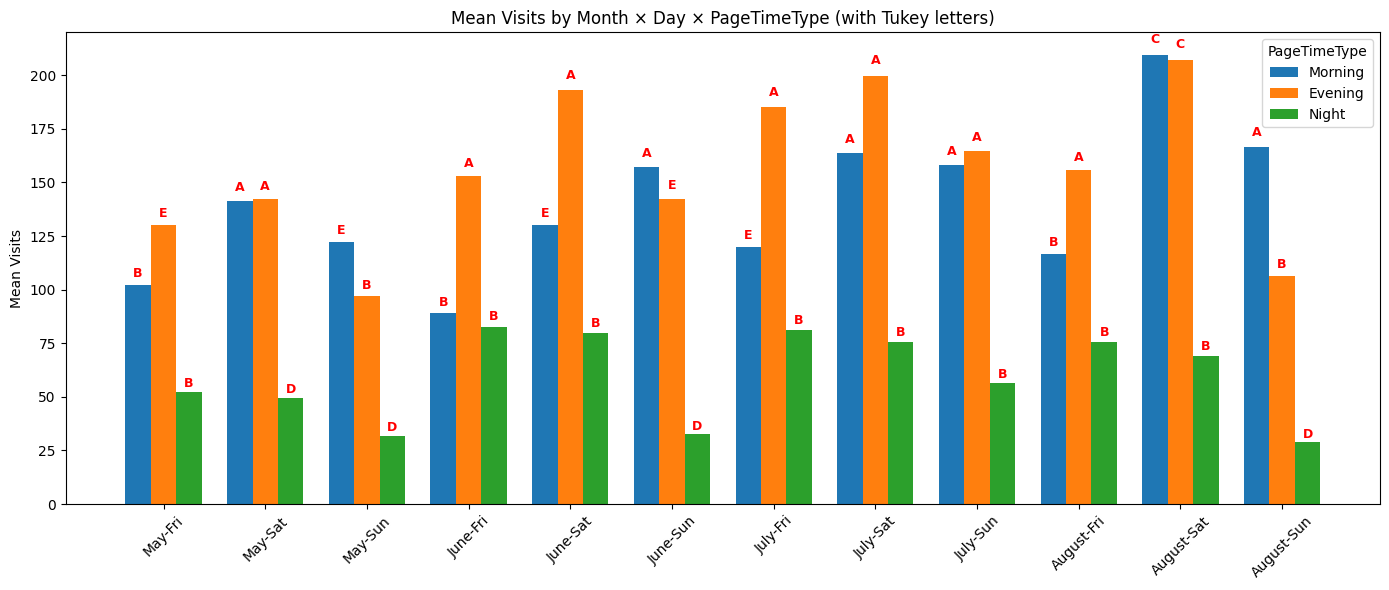

In [17]:
# ===== CONFIG =====
CSV = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
MONTHS = [5, 6, 7, 8]   # May–Aug
MONTH_NAME = {5:"May", 6:"June", 7:"July", 8:"August"}
DAYS = ["Friday", "Saturday", "Sunday"]
DAYPARTS = ["Morning", "Evening", "Night"]
COLORS = {"Morning":"tab:blue", "Evening":"tab:orange", "Night":"tab:green"}

# ----- IMPORTS -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ----- LOAD & PREP -----
df = pd.read_csv(CSV, low_memory=False)
df["date"]  = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["month"] = df["date"].dt.month
df["Day"]   = df["date"].dt.day_name()

def hh_cols(lo, hi):
    return [f"hh{h:02d}" for h in range(lo, hi+1) if f"hh{h:02d}" in df.columns]

# build dayparts
df["Morning"] = df[hh_cols(6,11)].sum(axis=1)
df["Evening"] = df[hh_cols(17,20)].sum(axis=1)
df["Night"]   = df[hh_cols(21,23)].sum(axis=1)

# keep May–Aug and Fri/Sat/Sun
df = df[df["month"].isin(MONTHS) & df["Day"].isin(DAYS)].copy()

# ----- Build long table (Month, Day, PageTimeType, Visits) -----
long = []
for part in DAYPARTS:
    tmp = df[["month","Day",part]].rename(columns={part:"Visits"}).copy()
    tmp["PageTimeType"] = part
    long.append(tmp)
long_df = pd.concat(long, ignore_index=True)
long_df["Group"] = long_df["month"].map(MONTH_NAME) + "-" + long_df["Day"].str[:3] + "-" + long_df["PageTimeType"]

# ----- Tukey letters -----
def tukey_letters(groups, values, alpha=0.05):
    tuk = pairwise_tukeyhsd(endog=np.asarray(values, dtype=float),
                            groups=np.asarray(groups, dtype=object),
                            alpha=alpha)
    tbl = pd.DataFrame(tuk._results_table.data[1:], columns=tuk._results_table.data[0])
    tbl["reject"] = tbl["reject"].astype(bool)
    unique = list(pd.unique(groups))
    ns = {g:set([g]) for g in unique}
    for _, r in tbl.iterrows():
        g1, g2, rej = r["group1"], r["group2"], r["reject"]
        if not rej:
            ns[g1].add(g2); ns[g2].add(g1)
    remaining = set(unique)
    labels = {g:set() for g in unique}
    letter = "A"
    while remaining:
        seed = sorted(remaining)[0]
        cluster = {seed}
        added = True
        while added:
            added = False
            for g in list(remaining - cluster):
                if cluster.issubset(ns[g]):
                    cluster.add(g); added = True
        for g in cluster:
            labels[g].add(letter)
        remaining -= cluster
        letter = chr(ord(letter)+1)
    return {g:"".join(sorted(v)) for g,v in labels.items()}, tuk

letters, tuk = tukey_letters(long_df["Group"], long_df["Visits"])
print(tuk.summary())

# ----- Plot all together -----
means = long_df.groupby(["month","Day","PageTimeType"])["Visits"].mean()

# x labels: May-Fri, May-Sat, May-Sun, … Aug-Sun
x_labels = [f"{MONTH_NAME[m]}-{d[:3]}" for m in MONTHS for d in DAYS]
x_pos = np.arange(len(x_labels))

bar_width = 0.25
fig, ax = plt.subplots(figsize=(14,6))

for i, part in enumerate(DAYPARTS):
    vals = [means.get((m,d,part),0) for m in MONTHS for d in DAYS]
    ax.bar(x_pos + (i-1)*bar_width, vals, width=bar_width,
           label=part, color=COLORS[part])
    # add letters
    for j,v in enumerate(vals):
        g = f"{x_labels[j]}-{part}"
        ax.text(x_pos[j] + (i-1)*bar_width, v*1.02 if v>0 else 0.5,
                letters.get(g,""), ha="center", va="bottom",
                fontsize=9, color="red", fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel("Mean Visits")
ax.set_title("Mean Visits by Month × Day × PageTimeType (with Tukey letters)")
ax.legend(title="PageTimeType")
plt.tight_layout()
plt.show()


               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
      group1             group2        meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------------------
August-Fri-Evening August-Fri-Morning  -38.9106 0.9595 -105.7992    27.978  False
August-Fri-Evening   August-Fri-Night   -80.139 0.0023 -147.0275  -13.2504   True
August-Fri-Evening August-Sat-Evening   51.5732 0.3972  -12.5385  115.6848  False
August-Fri-Evening August-Sat-Morning   53.8135 0.2985  -10.2982  117.9252  False
August-Fri-Evening   August-Sat-Night  -86.5618 0.0001 -150.6735  -22.4501   True
August-Fri-Evening August-Sun-Evening   -49.339 0.5891 -115.6101   16.9322  False
August-Fri-Evening August-Sun-Morning   11.0346    1.0  -55.2366   77.3057  False
August-Fri-Evening   August-Sun-Night -126.7871    0.0 -193.0583   -60.516   True
August-Fri-Evening   July-Fri-Evening   29.5524 0.9991  -34.6223    93.727  False
August-Fri-Eveni

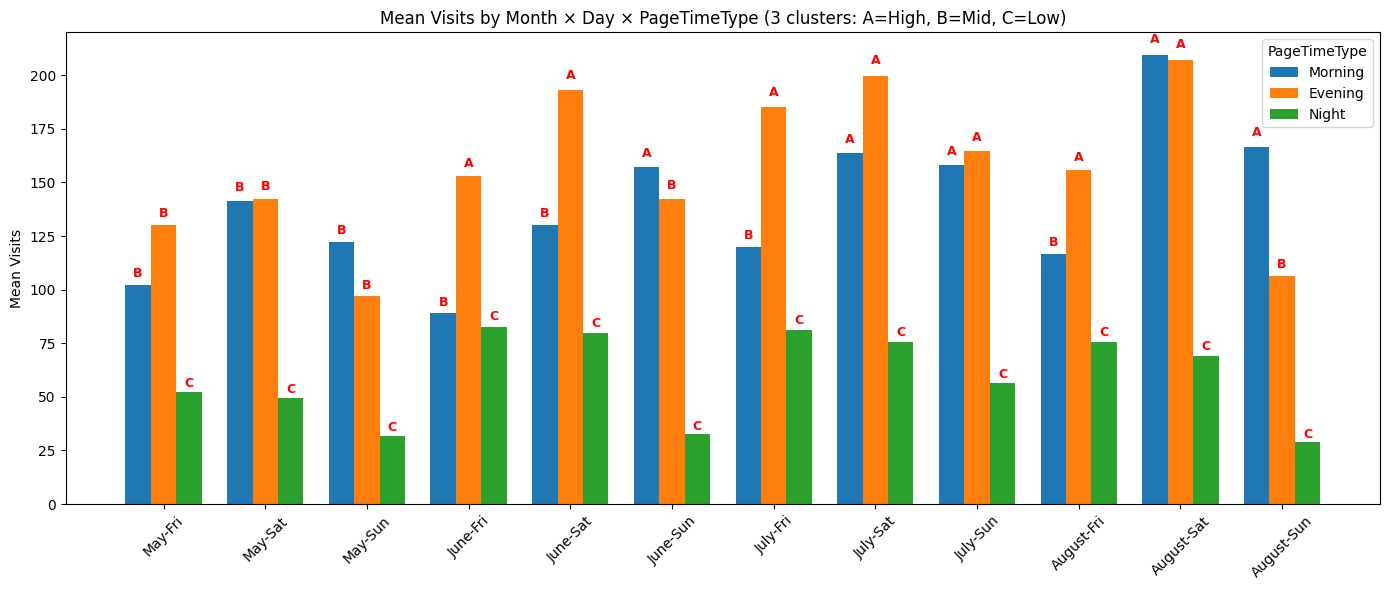

In [59]:
# ===== CONFIG =====
CSV = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
MONTHS = [5, 6, 7, 8]   # May–Aug
MONTH_NAME = {5:"May", 6:"June", 7:"July", 8:"August"}
DAYS = ["Friday", "Saturday", "Sunday"]
DAYPARTS = ["Morning", "Evening", "Night"]
COLORS = {"Morning":"tab:blue", "Evening":"tab:orange", "Night":"tab:green"}

# ===== IMPORTS =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ===== LOAD & PREP =====
df = pd.read_csv(CSV, low_memory=False)
df["date"]  = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["month"] = df["date"].dt.month
df["Day"]   = df["date"].dt.day_name()

def hh_cols(lo, hi):
    return [f"hh{h:02d}" for h in range(lo, hi+1) if f"hh{h:02d}" in df.columns]

# Build dayparts
df["Morning"] = df[hh_cols(6,11)].sum(axis=1)
df["Evening"] = df[hh_cols(17,20)].sum(axis=1)
df["Night"]   = df[hh_cols(21,23)].sum(axis=1)

# Keep May–Aug and Fri/Sat/Sun
df = df[df["month"].isin(MONTHS) & df["Day"].isin(DAYS)].copy()

# ===== Build long table (Month, Day, PageTimeType, Visits) =====
long = []
for part in DAYPARTS:
    tmp = df[["month","Day",part]].rename(columns={part:"Visits"}).copy()
    tmp["PageTimeType"] = part
    long.append(tmp)
long_df = pd.concat(long, ignore_index=True)
long_df["Group"] = (
    long_df["month"].map(MONTH_NAME) + "-" + long_df["Day"].str[:3] + "-" + long_df["PageTimeType"]
)

# ===== Tukey + Collapse to 3 clusters =====
def tukey_letters_3(groups, values, alpha=0.05):
    # Run Tukey (for info, not directly used in clustering here)
    tuk = pairwise_tukeyhsd(endog=np.asarray(values, dtype=float),
                            groups=np.asarray(groups, dtype=object),
                            alpha=alpha)
    # Compute group means
    df_means = pd.DataFrame({"Group": groups, "Value": values})
    means = df_means.groupby("Group")["Value"].mean().sort_values(ascending=False)

    # Split into 3 bins (A=high, B=mid, C=low)
    n = len(means)
    cut1 = n // 3
    cut2 = 2 * n // 3

    letters = {}
    for i, g in enumerate(means.index):
        if i < cut1:
            letters[g] = "A"
        elif i < cut2:
            letters[g] = "B"
        else:
            letters[g] = "C"

    return letters, tuk

letters, tuk = tukey_letters_3(long_df["Group"], long_df["Visits"])
print(tuk.summary())   # still shows Tukey test table

# ===== Plot all together =====
means = long_df.groupby(["month","Day","PageTimeType"])["Visits"].mean()

# x labels: May-Fri, May-Sat, May-Sun, … Aug-Sun
x_labels = [f"{MONTH_NAME[m]}-{d[:3]}" for m in MONTHS for d in DAYS]
x_pos = np.arange(len(x_labels))

bar_width = 0.25
fig, ax = plt.subplots(figsize=(14,6))

for i, part in enumerate(DAYPARTS):
    vals = [means.get((m,d,part),0) for m in MONTHS for d in DAYS]
    ax.bar(x_pos + (i-1)*bar_width, vals, width=bar_width,
           label=part, color=COLORS[part])
    # Add letters (A, B, C only)
    for j,v in enumerate(vals):
        g = f"{x_labels[j]}-{part}"
        ax.text(x_pos[j] + (i-1)*bar_width, v*1.02 if v>0 else 0.5,
                letters.get(g,""), ha="center", va="bottom",
                fontsize=9, color="red", fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_ylabel("Mean Visits")
ax.set_title("Mean Visits by Month × Day × PageTimeType (3 clusters: A=High, B=Mid, C=Low)")
ax.legend(title="PageTimeType")
plt.tight_layout()
plt.show()


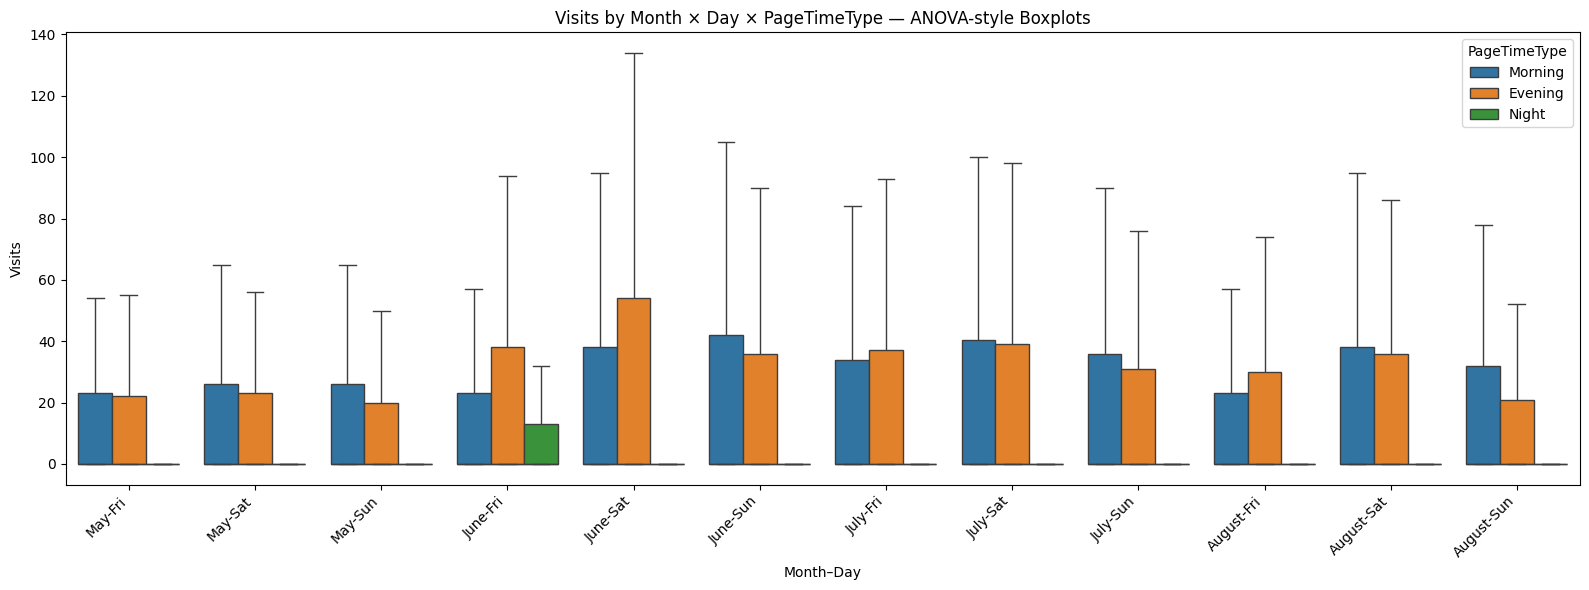

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MONTH_NAME = {5:"May", 6:"June", 7:"July", 8:"August"}
MONTHS     = [5,6,7,8]
DAYS       = ["Friday","Saturday","Sunday"]
DAYPARTS   = ["Morning","Evening","Night"]
PALETTE    = {"Morning":"tab:blue","Evening":"tab:orange","Night":"tab:green"}

# ---------- Ensure every (month, day, daypart) exists ----------
# Build the full grid of categories
grid = pd.MultiIndex.from_product([MONTHS, DAYS, DAYPARTS],
                                  names=["month","Day","PageTimeType"]).to_frame(index=False)

# Keep only May–Aug + Fri/Sat/Sun from your long_df
use = long_df[long_df["month"].isin(MONTHS) & long_df["Day"].isin(DAYS)
             & long_df["PageTimeType"].isin(DAYPARTS)].copy()

# Mark which combos are missing
have = use.groupby(["month","Day","PageTimeType"]).size().reset_index(name="n")
missing = grid.merge(have, how="left", on=["month","Day","PageTimeType"])
missing = missing[missing["n"].isna()].drop(columns=["n"])

# Add a tiny dummy observation for each missing combo so seaborn draws the box
# (It will appear as a very thin box/line at ~0.)
if not missing.empty:
    dummy = missing.assign(Visits=0.0001)  # tiny number to avoid log(0) issues if you switch scales
    use = pd.concat([use, dummy], ignore_index=True)

# ---------- Build x-axis labels ----------
use["MonthDay"] = use["month"].map(MONTH_NAME) + "-" + use["Day"].str[:3]
order = [f"{MONTH_NAME[m]}-{d[:3]}" for m in MONTHS for d in DAYS]

# ---------- One-diagram ANOVA-style boxplot ----------
plt.figure(figsize=(16,6))
sns.boxplot(
    x="MonthDay", y="Visits", hue="PageTimeType", data=use,
    order=order, hue_order=DAYPARTS, showfliers=False, palette=PALETTE
)

plt.title("Visits by Month × Day × PageTimeType — ANOVA-style Boxplots")
plt.xlabel("Month–Day")
plt.ylabel("Visits")
plt.xticks(rotation=45, ha="right")
plt.legend(title="PageTimeType")
plt.tight_layout()
plt.show()


In [54]:
import pandas as pd

# (Optional) normalize Day/PageTimeType once
def norm_day(s):
    s = str(s).strip().lower()
    if s.startswith("fri"): return "Friday"
    if s.startswith("sat"): return "Saturday"
    if s.startswith("sun"): return "Sunday"
    return s.title()

long_df["Day"] = long_df["Day"].map(norm_day)
# ensure PageTimeType is one of these strings already
# long_df["PageTimeType"] = long_df["PageTimeType"].replace({...})

# --- summary table ---
summary = (
    long_df
    .groupby(["month","Day","PageTimeType"])["Visits"]
    .agg(count="count", mean="mean", median="median", min="min", max="max")
    .reset_index()
)

# --- order helpers (use column names in sort_values) ---
month_order = {5:0, 6:1, 7:2, 8:3}
day_order   = {"Friday":0, "Saturday":1, "Sunday":2}
pt_order    = {"Morning":0, "Evening":1, "Night":2}

summary["__m"]  = summary["month"].map(month_order)
summary["__d"]  = summary["Day"].map(day_order)
summary["__pt"] = summary["PageTimeType"].map(pt_order)

summary = summary.sort_values(by=["__m","__d","__pt"]).drop(columns=["__m","__d","__pt"])

# (Optional) show month names
MONTH_NAME = {5:"May",6:"June",7:"July",8:"August"}
summary["month"] = summary["month"].map(MONTH_NAME)

print(summary.to_string(index=False))


 month      Day PageTimeType  count   mean  median  min       max
   May   Friday      Morning   1794 102.39    0.00 0.00  6,672.00
   May   Friday      Evening   1794 130.10    0.00 0.00  7,524.00
   May   Friday        Night   1794  52.32    0.00 0.00  3,455.00
   May Saturday      Morning   2027 141.56    0.00 0.00 11,120.00
   May Saturday      Evening   2027 142.44    0.00 0.00  5,443.00
   May Saturday        Night   2027  49.53    0.00 0.00  4,352.00
   May   Sunday      Morning   2399 122.06    0.00 0.00  6,564.00
   May   Sunday      Evening   2399  96.87    0.00 0.00  5,522.00
   May   Sunday        Night   2399  31.86    0.00 0.00  3,693.00
  June   Friday      Morning   2198  89.17    0.00 0.00  8,270.00
  June   Friday      Evening   2198 152.78    0.00 0.00 10,460.00
  June   Friday        Night   2198  82.76    0.00 0.00  8,022.00
  June Saturday      Morning   2843 129.98    0.00 0.00  7,518.00
  June Saturday      Evening   2843 192.91    0.00 0.00 14,704.00
  June Sat